In [49]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/advr93/fraud-detection-dataset/synthetic_fraud_dataset.csv


# Import Libraries

In [50]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection & preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

# Dataset Analysis and Visualization

In [51]:
# Load dataset (Kaggle path)
df = pd.read_csv("/kaggle/input/datasets/advr93/fraud-detection-dataset/synthetic_fraud_dataset.csv")

In [52]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [53]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='object')

In [54]:
#Columns and their unique values
for col in df.columns:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 20)

Unique values in column 'Transaction_ID':
['TXN_33553' 'TXN_9427' 'TXN_199' ... 'TXN_38158' 'TXN_860' 'TXN_15795']
--------------------
Unique values in column 'User_ID':
['USER_1834' 'USER_7875' 'USER_2734' ... 'USER_5657' 'USER_8613'
 'USER_5580']
--------------------
Unique values in column 'Transaction_Amount':
[ 39.79   1.19  28.96 ... 122.76 315.08 109.62]
--------------------
Unique values in column 'Transaction_Type':
['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']
--------------------
Unique values in column 'Timestamp':
['2023-08-14 19:30:00' '2023-06-07 04:01:00' '2023-06-20 15:25:00' ...
 '2023-01-30 19:32:00' '2023-03-09 19:47:00' '2023-08-19 23:57:00']
--------------------
Unique values in column 'Account_Balance':
[93213.17 75725.25  1588.96 ... 29916.41 67895.67  7668.82]
--------------------
Unique values in column 'Device_Type':
['Laptop' 'Mobile' 'Tablet']
--------------------
Unique values in column 'Location':
['Sydney' 'New York' 'Mumbai' 'Tokyo' 'London']
-----

**Distribution of Numerical Features**

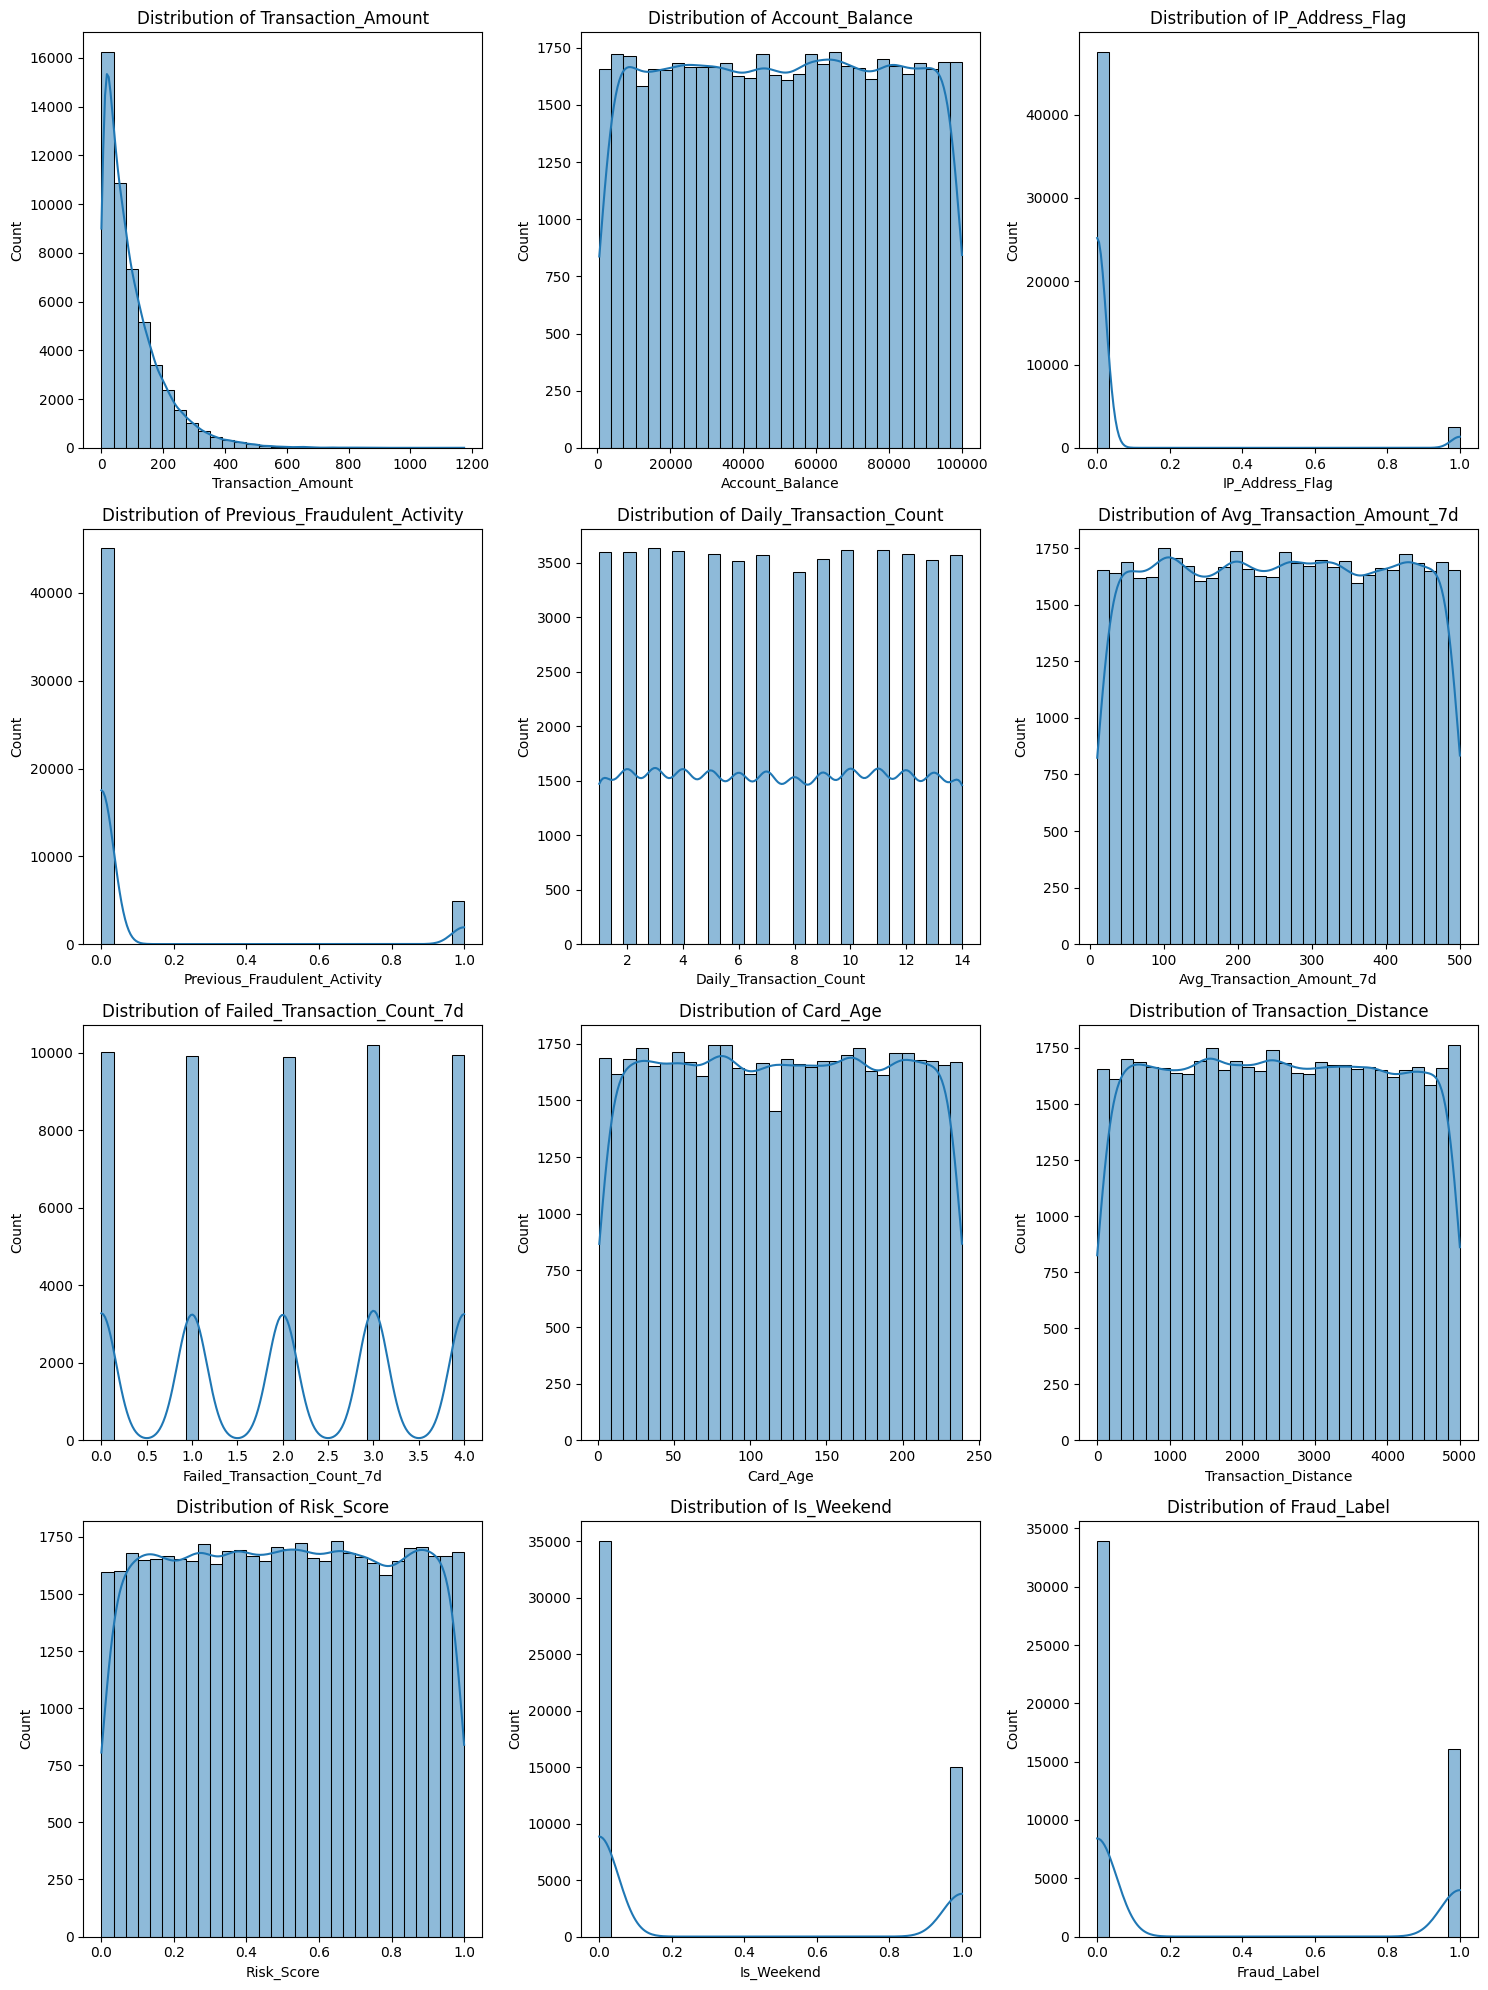

In [55]:
# Select only numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# Define grid layout (e.g., 3 columns and dynamic rows)
n_cols = 3  # Number of columns
n_rows = -(-len(num_cols) // n_cols)  # Ceiling division to calculate rows

# Create subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array if it's 2D
axes = axes.flatten()

# Create histograms for each numerical column
for i, column in enumerate(num_cols):
    sns.histplot(df[column], bins=30, kde=True, ax=axes[i])  # Histogram with KDE
    axes[i].set_title(f'Distribution of {column}')

# Hide any empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**Target Class Distribution**

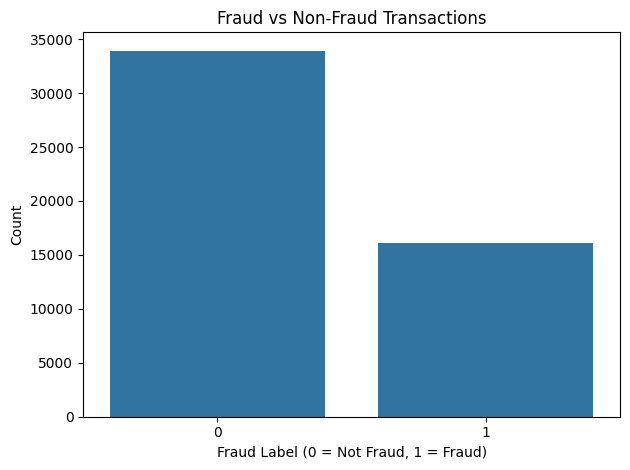

In [56]:

sns.countplot(x=df['Fraud_Label'])
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Preprocessing

In [57]:
# Reduce memory
for col in df.select_dtypes(include=['float64']):
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']):
    df[col] = df[col].astype('int32')
# Handle categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].nunique() > 50:
        df.drop(col, axis=1, inplace=True)
# reduce prediction leakage
df = df.drop(columns='Risk_Score')
# Basic preprocessing
df = pd.get_dummies(df, drop_first=True)
X = df.drop("Fraud_Label", axis=1)
y = df["Fraud_Label"]
#del df


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# RQ1: Baseline Performance

In [58]:
def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]

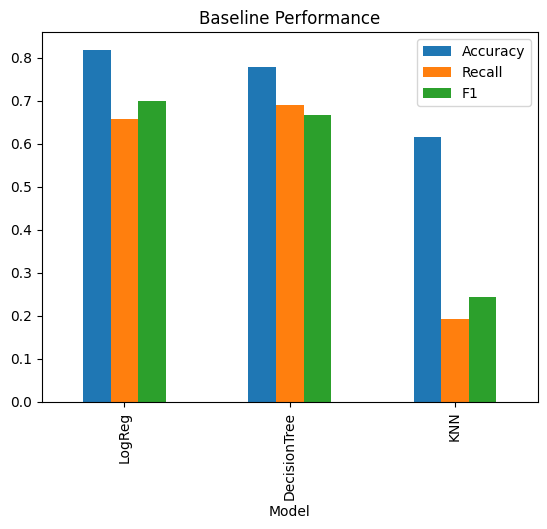

In [59]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    res = evaluate(model)
    results.append([name] + res)

df_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
df_results.to_csv("RQ1_table.csv", index=False)

df_results.plot(x="Model", y=["Accuracy","Recall","F1"], kind="bar")
plt.title("Baseline Performance")
plt.savefig("RQ1_figure.pdf")
plt.show()

In [60]:
df_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,LogReg,0.8183,0.746643,0.657641,0.699322,0.798629
1,DecisionTree,0.7780,0.644373,0.689698,0.666266,0.754750
2,KNN,0.6147,0.329424,0.192344,0.242877,0.500602


# RQ2: Advanced Model Comparision

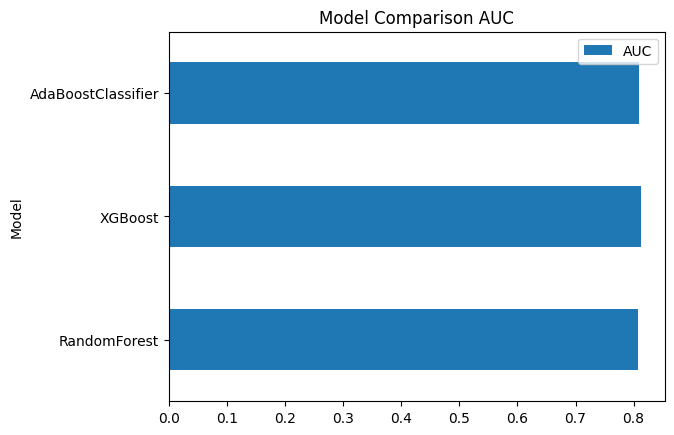

In [61]:
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "AdaBoostClassifier" : AdaBoostClassifier(n_estimators=50, learning_rate=0.3, random_state=101)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    res = evaluate(model)
    results.append([name] + res)

df_adv_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
df_adv_results.to_csv("RQ2_table.csv", index=False)

df_adv_results.plot(x="Model", y="AUC", kind="barh")
plt.title("Model Comparison AUC")
plt.savefig("RQ2_figure.pdf")
plt.show()


In [62]:
df_adv_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,RandomForest,0.8772,1.000000,0.617803,0.763755,0.808299
1,XGBoost,0.8750,0.987097,0.619048,0.760903,0.812986
2,AdaBoostClassifier,0.8772,1.000000,0.617803,0.763755,0.808901


# RQ3: Improving Recall through Scaling and SMOTE

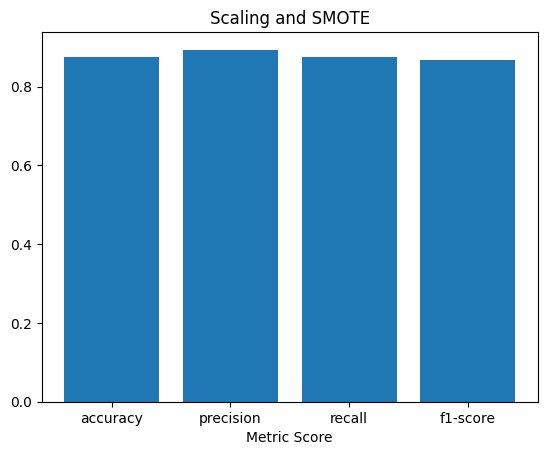

{'accuracy': 0.8757, 'precision': 0.8934098, 'recall': 0.8757, 'f1-score': 0.8663367297353997}


In [63]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from tabulate import tabulate


# Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]
# Print Results
clf_report=classification_report(y_test, y_pred, output_dict=True)
plot_data={}
plot_data['accuracy'] = clf_report['accuracy']
plot_data.update(clf_report['weighted avg'])
del plot_data['support']

plt.bar(plot_data.keys(), plot_data.values())

# Add labels
plt.xlabel('Metric Score')
plt.title('Scaling and SMOTE')

plt.show()
print(plot_data)

# RQ4: Feature Importance and Interpretability

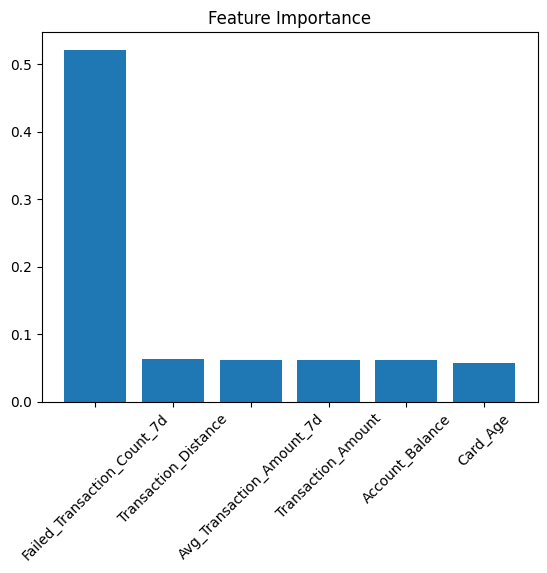

In [64]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = model.feature_importances_

df_feat = pd.DataFrame({"Feature": X.columns, "Importance": importances})
df_feat = df_feat.sort_values(by="Importance", ascending=False).head(6)

df_feat.to_csv("RQ4_table.csv", index=False)

plt.bar(df_feat["Feature"], df_feat["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.savefig("RQ4_figure.pdf")
plt.show()


# RQ5: Temporal Fraud Dynamics

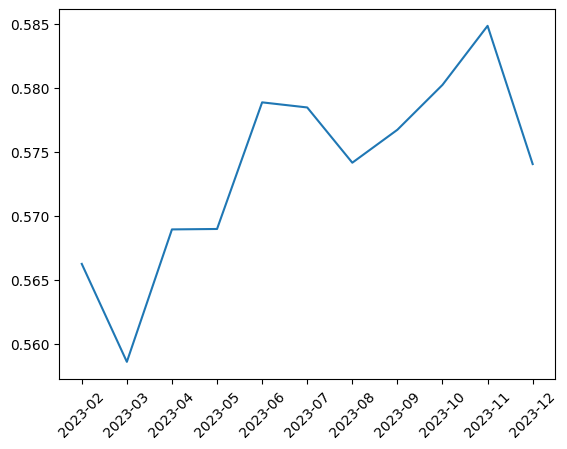

In [65]:
df = pd.read_csv("/kaggle/input/datasets/advr93/fraud-detection-dataset/synthetic_fraud_dataset.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['month'] = df['Timestamp'].dt.to_period('M')
df = df.drop(columns='Risk_Score')

results = []

for month in df['month'].unique():
    train = df[df['month'] < month]
    test = df[df['month'] == month]

    if len(train) == 0 or len(test) == 0:
        continue

    model = RandomForestClassifier()
    model.fit(train[['Transaction_Amount']], train['Fraud_Label'])

    acc = model.score(test[['Transaction_Amount']], test['Fraud_Label'])
    results.append([str(month), acc])

res_df = pd.DataFrame(results, columns=["Month","Accuracy"])
res_df = res_df.sort_values(by='Month')
res_df.to_csv("rq6_drift_table.csv", index=False)

plt.figure()
plt.plot(res_df['Month'], res_df['Accuracy'])
plt.xticks(rotation=45)
plt.savefig("rq6_drift_plot.pdf")
plt.show()


# RQ6: Feature Interaction Effects

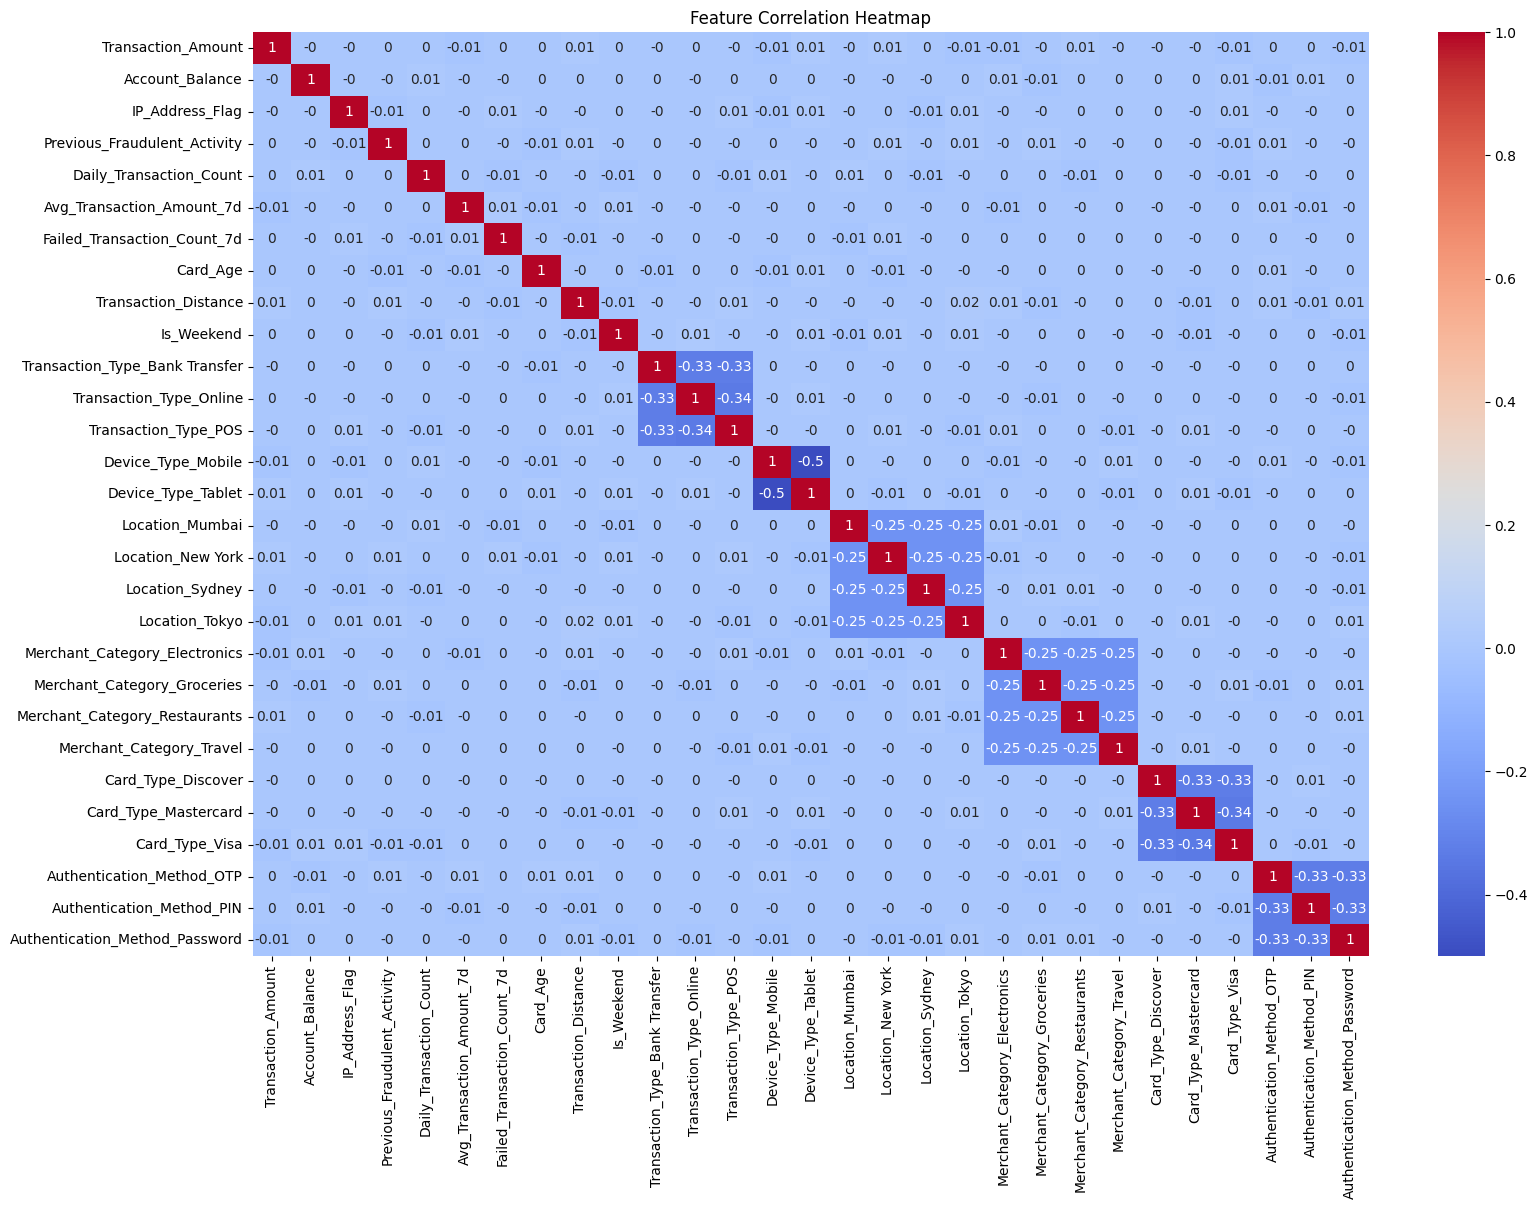

In [66]:
corr_matrix = X.corr(numeric_only=True).round(2)
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# RQ7: Robustness and Generalization

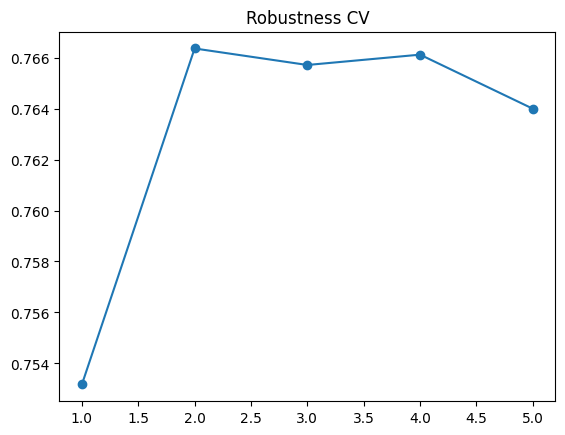

In [67]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

scores = cross_val_score(model, X, y, cv=5, scoring='f1')

df_results = pd.DataFrame({"Fold": range(1,6), "F1": scores})
df_results.to_csv("RQ6_table.csv", index=False)

plt.plot(df_results["Fold"], df_results["F1"], marker='o')
plt.title("Robustness CV")
plt.savefig("RQ6_figure.pdf")
plt.show()

In [68]:
print(df_results)

   Fold        F1
0     1  0.753172
1     2  0.766362
2     3  0.765714
3     4  0.766120
4     5  0.763998
